In [144]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [145]:
from google.colab import files
df = pd.read_csv("/content/drive/MyDrive/Practice Dataset/DataCoSupplyChainDataset.csv",
                 encoding = "latin1")

In [146]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Region,Order State,Order Status,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.25,$314.64,Advance shipping,0,73,Sporting Goods,Caguas,...,Southeast Asia,Java Occidental,COMPLETE,1360.0,73,Smart watch,$327.75,0,2/3/2018,Standard Class
1,TRANSFER,5,4,-249.09,$311.36,Late delivery,1,73,Sporting Goods,Caguas,...,South Asia,Rajastán,PENDING,1360.0,73,Smart watch,$327.75,0,1/18/2018,Standard Class
2,CASH,4,4,-247.78,$309.72,Shipping on time,0,73,Sporting Goods,San Jose,...,South Asia,Rajastán,CLOSED,1360.0,73,Smart watch,$327.75,0,1/17/2018,Standard Class
3,DEBIT,3,4,22.86,$304.81,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Oceania,Queensland,COMPLETE,1360.0,73,Smart watch,$327.75,0,1/16/2018,Standard Class
4,PAYMENT,2,4,134.21,$298.25,Advance shipping,0,73,Sporting Goods,Caguas,...,Oceania,Queensland,PENDING_PAYMENT,1360.0,73,Smart watch,$327.75,0,1/15/2018,Standard Class


In [147]:
df.shape

(180519, 47)

In [148]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Fname', 'Customer Id', 'Customer Lname',
       'Customer Segment', 'Customer State', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       ' Order Item Discount ', 'Order Item Discount Rate', 'Order Item Id',
       ' Order Item Product Price ', 'Order Item Profit Ratio',
       'Order Item Quantity', ' Sales ', ' Order Item Total ',
       ' Order Profit Per Order ', 'Order Region', 'Order State',
       'Order Status', 'Product Card Id', 'Product Category Id',
       'Product Name', ' Product Price ', 'Product Status',
       'shipping date (DateOrd

In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 47 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  object 
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Fname                 180519 non-null  object 
 12  Customer Id                   

In [150]:
numeric_columns = [
    "Sales per customer",
    " Order Item Discount ",
    "Order Item Discount Rate",
    " Order Item Product Price ",
    "Order Item Profit Ratio",
    " Sales ",
    " Order Item Total ",
    " Order Profit Per Order ",
    " Product Price "
]

for col in numeric_columns:
    df [col] = (
        df[col]
        .astype(str)
        .str.replace(',','',regex = False)
        .str.replace('$','',regex = False)
    )
    df[col] = pd.to_numeric(df[col], errors= 'coerce')

In [151]:
df["order date (DateOrders)"] = pd.to_datetime(
    df["order date (DateOrders)"], errors="coerce"
)

df["shipping date (DateOrders)"] = pd.to_datetime(
    df["shipping date (DateOrders)"], errors="coerce"
)

In [152]:
id_columns = [
    "Category Id",
    "Customer Id",
    "Department Id",
    "Order Customer Id",
    "Order Id",
    "Order Item Cardprod Id",
    "Order Item Id",
    "Product Category Id",
    "Product Status"
]

df[id_columns] = df[id_columns].astype("int64")

In [153]:
df["Customer Zipcode"] = df["Customer Zipcode"].astype("Int64")
df["Product Card Id"] = df["Product Card Id"].astype("Int64")

In [154]:
category_columns = [
    "Type",
    "Delivery Status",
    "Category Name",
    "Customer Country",
    "Customer Segment",
    "Department Name",
    "Market",
    "Order Country",
    "Order Region",
    "Order Status",
    "Product Name",
    "Shipping Mode"
]

for col in category_columns:
    df[col] = df[col].astype("category")

In [155]:
df.columns.str.strip()

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Fname', 'Customer Id', 'Customer Lname',
       'Customer Segment', 'Customer State', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Product Card Id', 'Product Category Id', 'Product Name',
       'Product Price', 'Product Status', 'shipping date (DateOrders)',
       'Ship

In [156]:
df.columns = df.columns.str.strip().str.replace(" ","_")

In [157]:
df.isnull().sum()

,0
Type,0
Days_for_shipping_(real),0
Days_for_shipment_(scheduled),0
Benefit_per_order,0
Sales_per_customer,0
Delivery_Status,0
Late_delivery_risk,0
Category_Id,0
Category_Name,0
Customer_City,0


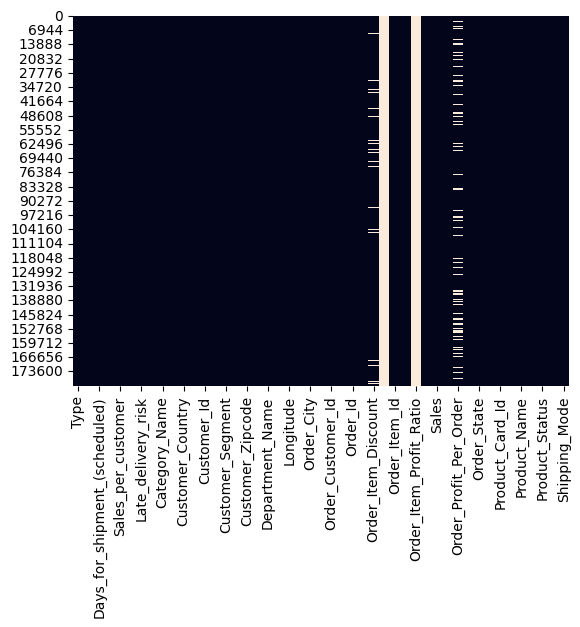

In [158]:
sns.heatmap(df.isnull(),cbar = False)
plt.show()

In [159]:
df.drop(columns = [
    'Order_Item_Discount_Rate',
    'Order_Item_Profit_Ratio'
], inplace = True)

In [176]:
numeric_columns = [
    'Benefit_per_order',
    'Sales_per_customer',
    'Order_Item_Discount',
    'Order_Item_Product_Price',
    'Sales',
    'Order_Item_Total',
    'Order_Profit_Per_Order',
    'Product_Price',
]
numeric_columns = [col for col in numeric_columns if col in df.columns]

In [162]:
df['Customer_Lname'] = df['Customer_Lname'].fillna('Unknown')

In [163]:
df['Customer_Zipcode'] = df['Customer_Zipcode'].fillna(df['Customer_Zipcode'].mode()[0])

In [164]:
df['Product_Card_Id'] = df['Product_Card_Id'].fillna(df['Product_Card_Id'].mode()[0])

In [165]:
df['Order_Item_Discount'] = df['Order_Item_Discount'].fillna(0)

In [166]:
df['Order_Profit_Per_Order'] = df['Order_Profit_Per_Order'].fillna(df['Order_Profit_Per_Order'].median())

In [167]:
df.duplicated().sum()

np.int64(0)

In [169]:
df.isnull().sum()

,0
Type,0
Days_for_shipping_(real),0
Days_for_shipment_(scheduled),0
Benefit_per_order,0
Sales_per_customer,0
Delivery_Status,0
Late_delivery_risk,0
Category_Id,0
Category_Name,0
Customer_City,0


In [170]:
df.nunique()

,0
Type,4
Days_for_shipping_(real),7
Days_for_shipment_(scheduled),4
Benefit_per_order,21998
Sales_per_customer,2927
Delivery_Status,4
Late_delivery_risk,2
Category_Id,51
Category_Name,50
Customer_City,563


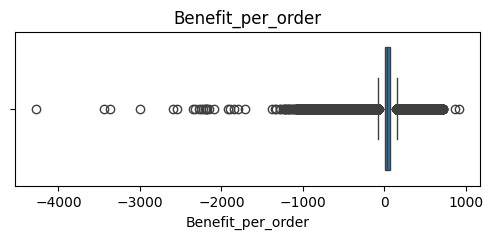

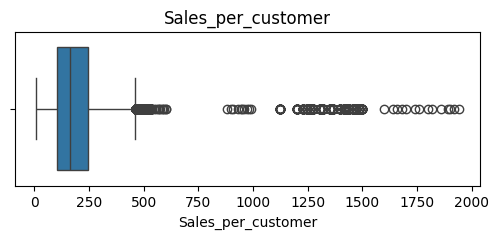

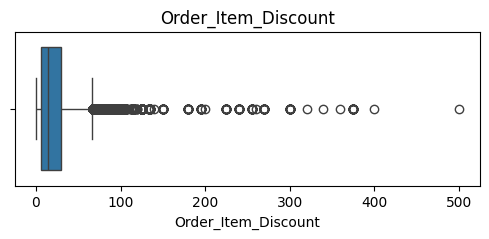

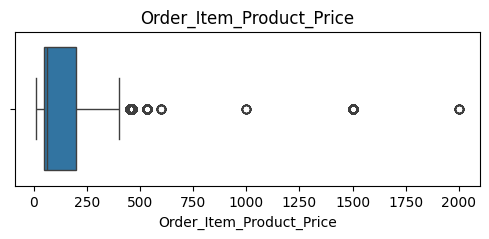

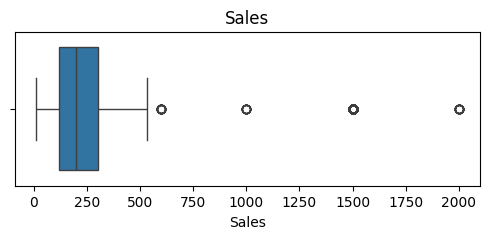

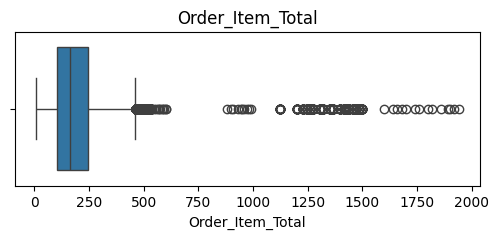

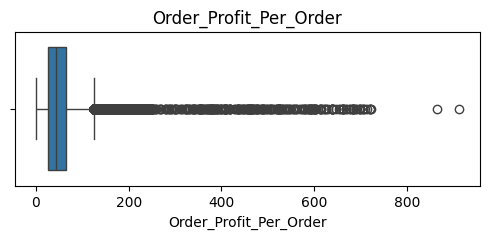

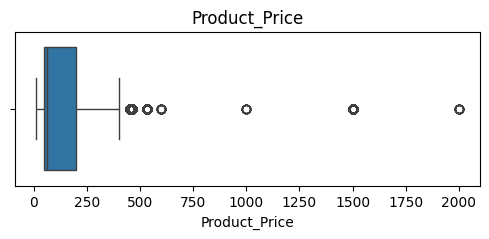

In [177]:
for col in numeric_columns:
  plt.figure(figsize =(6,2))
  sns.boxplot(x = df[col])
  plt.title(col)
  plt.show()

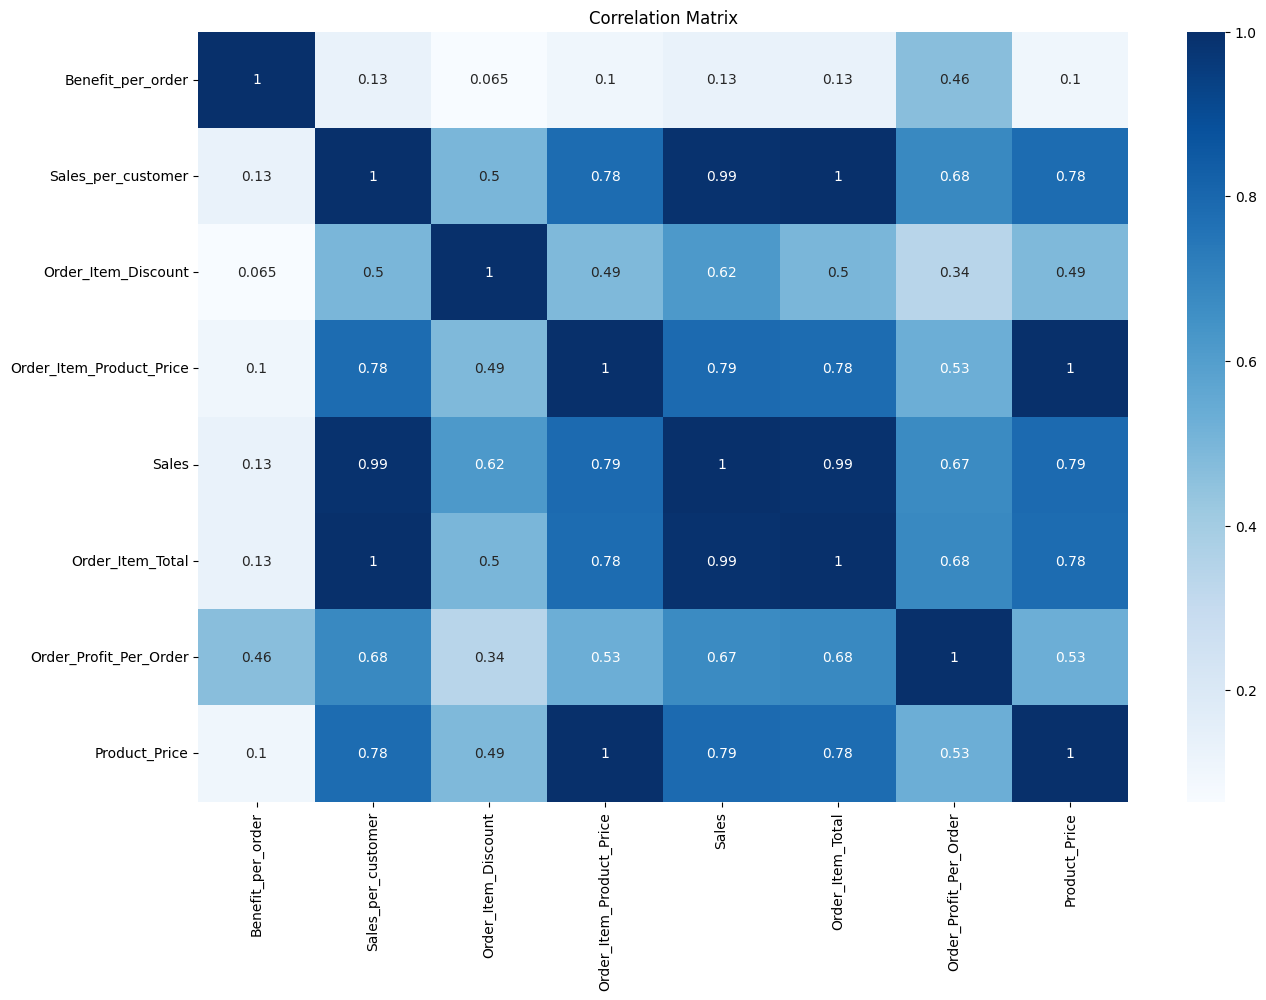

In [178]:
corr = df[numeric_columns].corr()
plt.figure(figsize = (15,10))
sns.heatmap(corr, annot = True, cmap='Blues')
plt.title('Correlation Matrix')
plt.show()

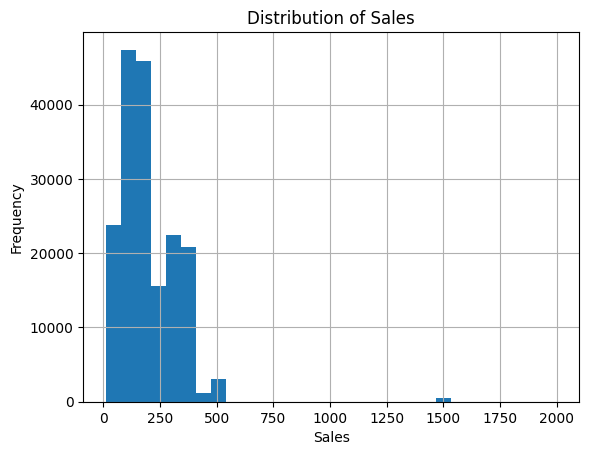

In [179]:
df['Sales'].hist(bins=30)
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.title('Distribution of Sales')
plt.show()

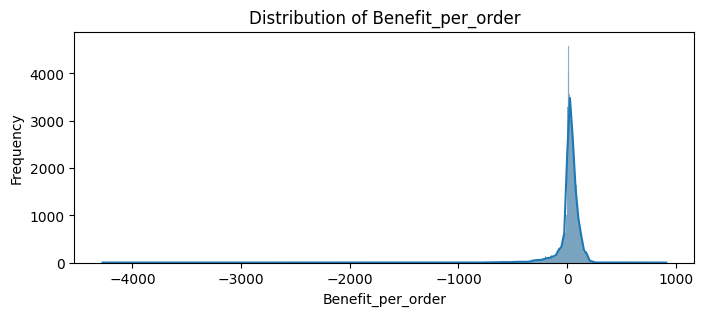

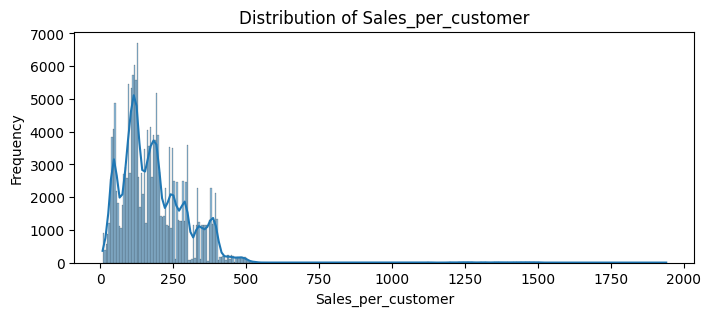

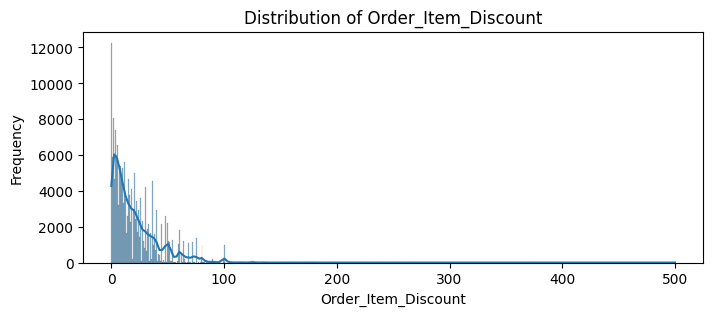

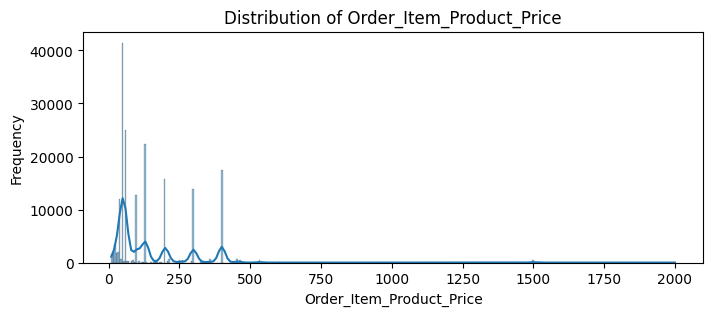

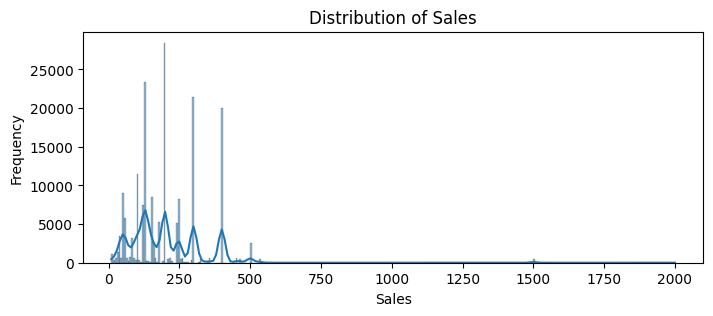

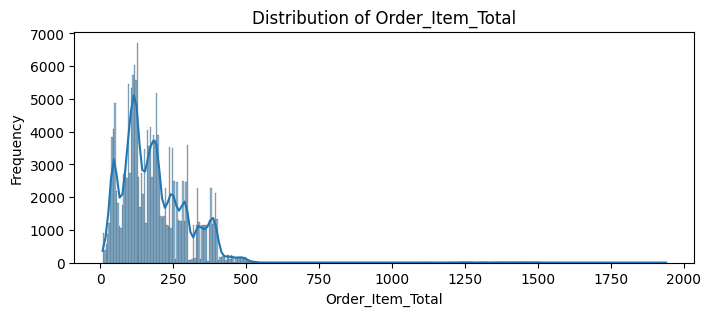

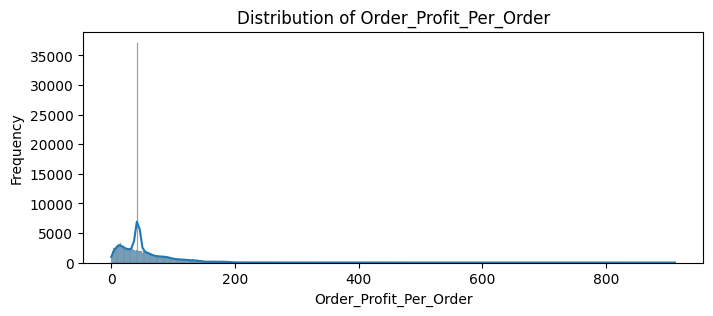

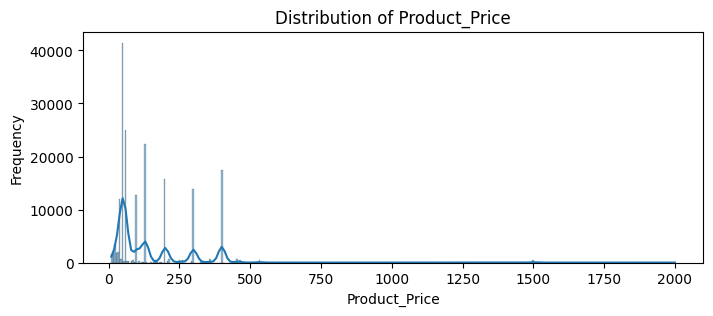

In [180]:
for col in numeric_columns:
    plt.figure(figsize=(8, 3))
    sns.histplot(df[col], kde=True)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {col}')
    plt.show()

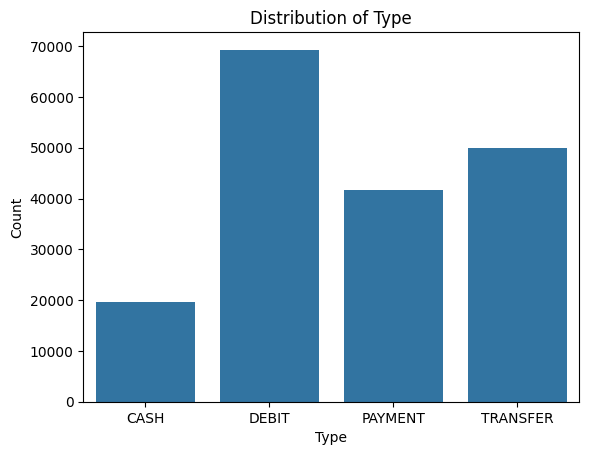

In [181]:
sns.countplot(x='Type', data=df)
plt.xticks(rotation=00)
plt.xlabel('Type')
plt.ylabel('Count')
plt.title('Distribution of Type')
plt.show()

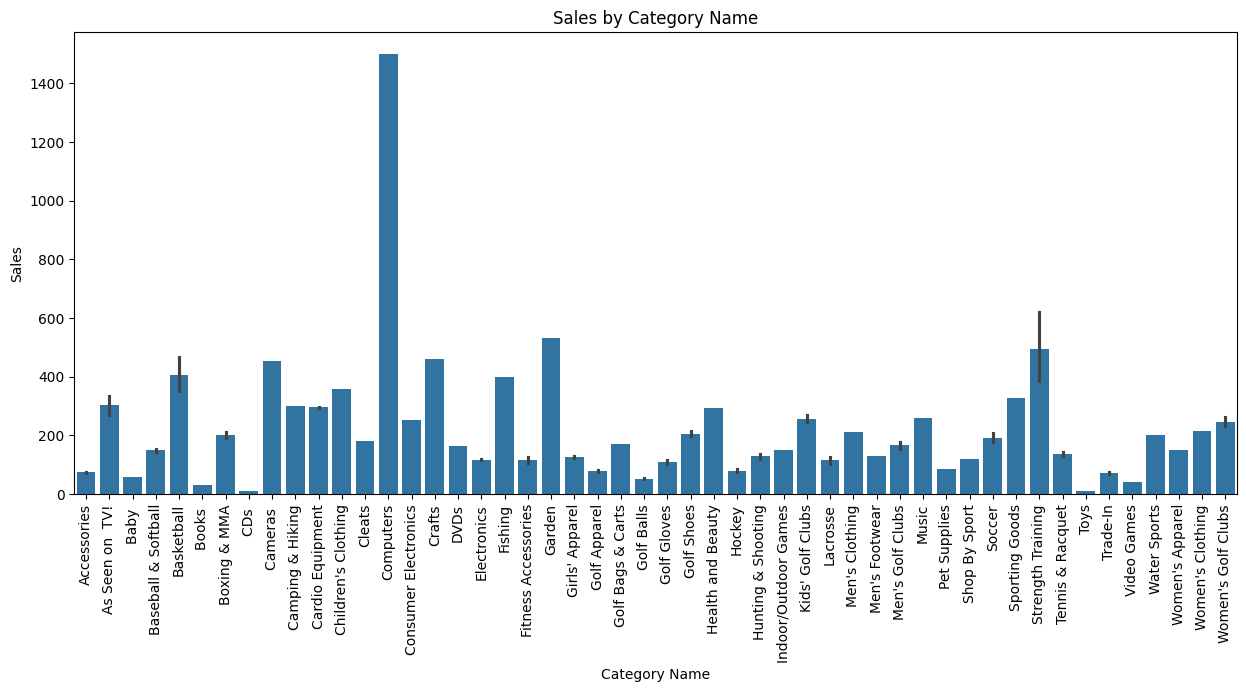

In [182]:
plt.figure(figsize=(15,6))
sns.barplot(x='Category_Name', y='Sales', data=df)
plt.xticks(rotation=90)
plt.xlabel('Category Name')
plt.ylabel('Sales')
plt.title('Sales by Category Name')
plt.show()

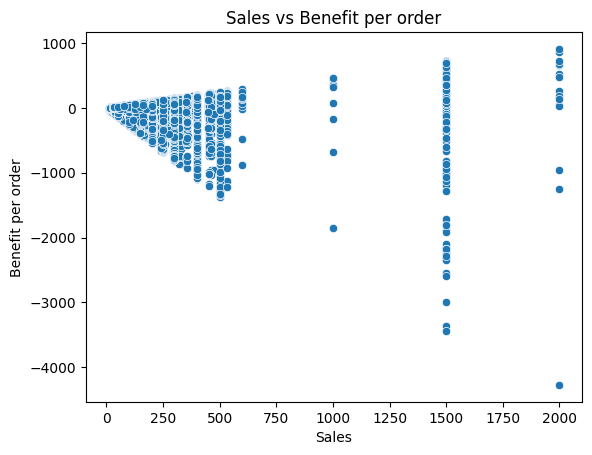

In [183]:
sns.scatterplot(x='Sales', y='Benefit_per_order', data=df)
plt.xlabel('Sales')
plt.ylabel('Benefit per order')
plt.title('Sales vs Benefit per order')
plt.show()

In [187]:
df.groupby('Category_Name', observed=False).agg({
    'Sales':['sum','mean'],
    'Benefit_per_order':'mean'
})

Sales              Benefit_per_order
                             sum         mean              mean
Category_Name                                                  
Accessories            133671.51    75.096354          9.350292
As Seen on  TV!         20597.94   302.910882         10.506324
Baby                    12229.56    59.080000          7.367295
Baseball & Softball     94057.15   148.824604         20.193244
Basketball              27099.33   404.467612         27.547313
Books                   12587.40    31.080000          2.180272
Boxing & MMA            85205.41   201.431229         20.428771
CDs                      3059.59    11.290000          1.416421
Cameras                267607.68   452.040000         51.165203
Camping & Hiking      4118425.42   299.980000         31.135230
Cardio Equipment      3694843.20   295.895187         30.672788
Children's Clothing    232829.20   357.100000         41.684202
Cleats                4431942.66   180.519843         20.147323
Computers              663000.00  1500.000000        157.594593
Consumer Electronics   108991.28   252.880000         30.680742
Crafts                 223356.32   461.480000         52.750351
DVDs                    79395.54   164.380000         13.779358
Electronics            371034.64   117.564842         12.956711
Fishing               6929653.50   399.980000         43.649106
Fitness Accessories     35601.44   115.215016         17.017443
Garden                 257768.72   532.580000         69.097128
Girls' Apparel         151706.20   126.316570         14.395146
Golf Apparel            34969.75    79.296485          7.928141
Golf Bags & Carts       10369.39   169.990000         29.673279
Golf Balls              77098.16    52.269939          5.656047
Golf Gloves            116695.39   109.061112         12.126626
Golf Shoes             107998.00   206.103053         23.675706
Health and Beauty      106080.48   293.040000         26.225497
Hockey                  48360.73    78.763404          8.790603
Hunting & Shooting      56848.42   129.200955         13.590909
Indoor/Outdoor Games  2888993.94   149.704319         16.501784
Kids' Golf Clubs        98797.58   257.285365         23.556875
Lacrosse                39464.79   115.057697         12.723878
Men's Clothing          43856.80   210.850000          9.644423
Men's Footwear        2891757.54   129.990000         14.020625
Men's Golf Clubs        47035.80   166.204240         19.498198
Music                  113122.10   260.650000         33.263410
Pet Supplies            41524.80    84.400000          7.295244
Shop By Sport         1309522.02   119.220869         11.818460
Soccer                  26477.05   191.862681         28.275000
Sporting Goods         117006.75   327.750000         35.066134
Strength Training       54895.53   494.554324          2.993784
Tennis & Racquet        44585.09   135.930152         17.524329
Toys                     6104.66    11.540000          1.702665
Trade-In                68721.78    70.556242          8.126663
Video Games             33310.50    39.750000          3.242864
Water Sports          3113844.60   200.376100         20.923228
Women's Apparel       3147800.00   149.645828         16.658951
Women's Clothing       140283.00   215.820000         29.389000
Women's Golf Clubs      44545.97   246.110331         27.782541

In [189]:
df['Year'] = df['order_date_(DateOrders)'].dt.year
df['Month'] = df['order_date_(DateOrders)'].dt.month

In [190]:
df['Profit_margin'] = (df['Order_Profit_Per_Order'] / df['Sales']) * 100

In [226]:
top_products = df.groupby('Product_Name', observed=False)['Sales'].sum().nlargest(10)
top_products.to_frame()

,Sales
Product_Name,
Field & Stream Sportsman 16 Gun Fire Safe,6929653.50
Perfect Fitness Perfect Rip Deck,4421143.02
Diamondback Women's Serene Classic Comfort Bi,4118425.42
Nike Men's Free 5.0+ Running Shoe,3667633.20
Nike Men's Dri-FIT Victory Golf Polo,3147800.00
Pelican Sunstream 100 Kayak,3099845.00
Nike Men's CJ Elite 2 TD Football Cleat,2891757.54
O'Brien Men's Neoprene Life Vest,2888993.94
Under Armour Girls' Toddler Spine Surge Runni,1269082.65


In [227]:
top_loss_making_products = df.groupby('Product_Name', observed=False)['Order_Profit_Per_Order'].sum().nlargest(10)
top_loss_making_products.to_frame()

,Order_Profit_Per_Order
Product_Name,
Field & Stream Sportsman 16 Gun Fire Safe,1626699.930
Perfect Fitness Perfect Rip Deck,1147868.865
Diamondback Women's Serene Classic Comfort Bi,985185.605
Nike Men's Free 5.0+ Running Shoe,880627.495
Nike Men's Dri-FIT Victory Golf Polo,847684.830
Nike Men's CJ Elite 2 TD Football Cleat,805618.970
Pelican Sunstream 100 Kayak,785565.185
O'Brien Men's Neoprene Life Vest,777441.775
Under Armour Girls' Toddler Spine Surge Runni,358248.815


In [221]:
top_customers = df.groupby('Customer_Id', observed=False)['Sales'].sum().nlargest(10)
top_customers.to_frame()

,Sales
Customer_Id,
791,10524.17
9371,9299.03
8766,9296.14
1657,9223.71
2641,9130.92
1288,9019.11
3710,9019.10
4249,8918.85
5654,8904.95


In [222]:
top_categories = df.groupby('Category_Name', observed=False)['Sales'].sum().nlargest(10)
top_categories.to_frame()

,Sales
Category_Name,
Fishing,6929653.50
Cleats,4431942.66
Camping & Hiking,4118425.42
Cardio Equipment,3694843.20
Women's Apparel,3147800.00
Water Sports,3113844.60
Men's Footwear,2891757.54
Indoor/Outdoor Games,2888993.94
Shop By Sport,1309522.02


In [225]:
top_countries = df.groupby('Order_Country', observed=False)['Sales'].sum().nlargest(10)
top_countries.to_frame()

,Sales
Order_Country,
Estados Unidos,4879667.57
Francia,2879942.31
México,2633195.24
Alemania,2074171.78
Australia,1694621.64
Reino Unido,1612094.82
Brasil,1594319.92
China,1172902.09
Italia,1072181.65


In [228]:
top_regions = df.groupby('Order_Region', observed=False)['Sales'].sum()
top_regions.to_frame()

,Sales
Order_Region,
Canada,186861.04
Caribbean,1651019.30
Central Africa,327263.01
Central America,5665711.99
Central Asia,109839.93
East Africa,376234.89
East of USA,1371111.96
Eastern Asia,1486401.31
Eastern Europe,774266.55


In [209]:
print(df[['Order_Item_Discount','Order_Profit_Per_Order']].corr())

                        Order_Item_Discount  Order_Profit_Per_Order
Order_Item_Discount                1.000000                0.340096
Order_Profit_Per_Order             0.340096                1.000000


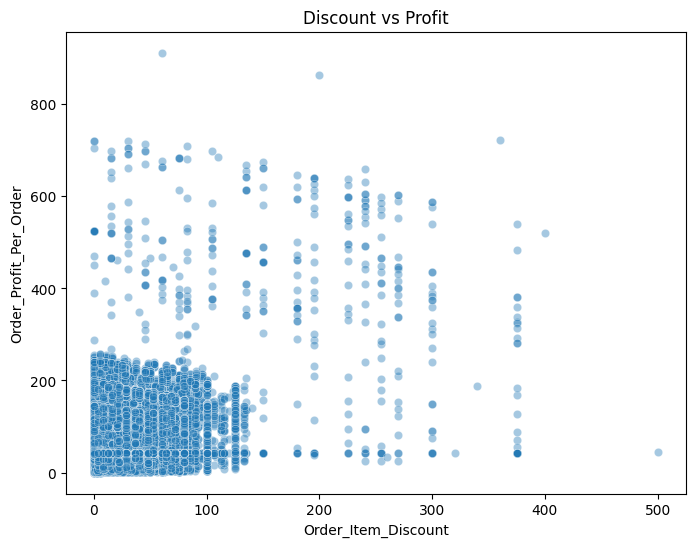

In [211]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Order_Item_Discount',
    y='Order_Profit_Per_Order',
    data=df,
    alpha=0.4)
plt.title("Discount vs Profit")
plt.show()

In [198]:
Avg_delivery_days = (df['Days_for_shipping_(real)']).mean()
print(Avg_delivery_days)

3.4976539865609713


In [200]:
Late_deliveries = df['Late_delivery_risk'].value_counts()
print(Late_deliveries)

Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64


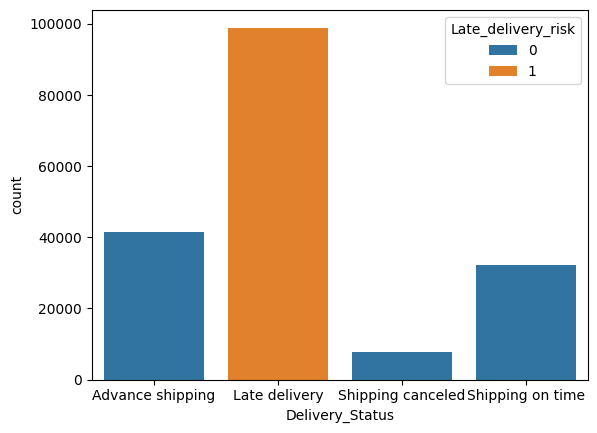

In [208]:
sns.countplot(x='Delivery_Status', hue= 'Late_delivery_risk', data=df)

plt.show()

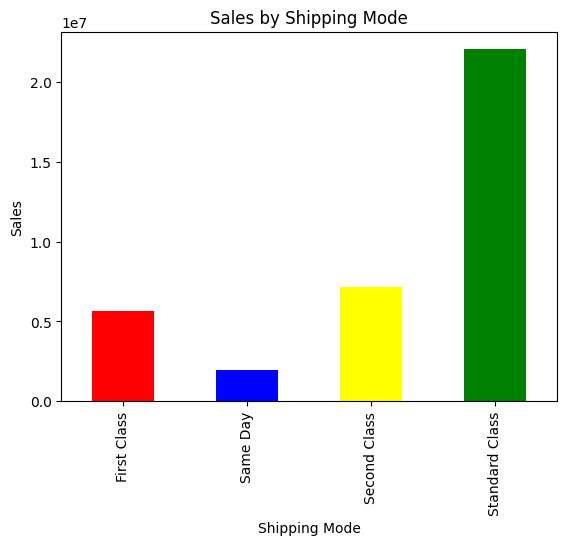

In [215]:
best_shipping_mode = df.groupby('Shipping_Mode', observed=False)['Sales'].sum()
best_shipping_mode.plot(kind='bar', color=['red', 'blue', 'yellow', 'green'] , title='Sales by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Sales')
plt.show()

In [202]:
df['Shipping_Mode'].value_counts()

,count
Shipping_Mode,
Standard Class,107752
Second Class,35216
First Class,27814
Same Day,9737


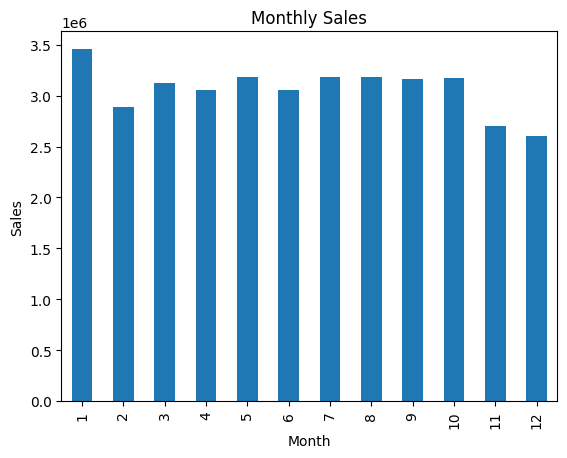

In [203]:
monthly = df.groupby('Month', observed=False)['Sales'].sum()
monthly.plot(kind='bar', title='Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

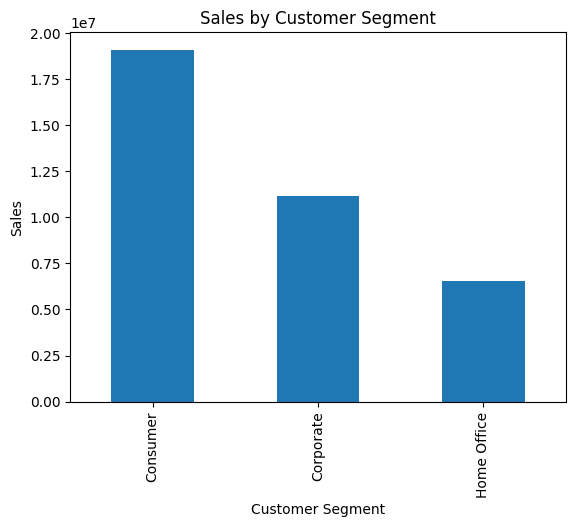

In [217]:
Sales_by_customer_segment = df.groupby('Customer_Segment', observed=False)['Sales'].sum()
Sales_by_customer_segment.plot(kind='bar', title='Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Sales')
plt.show()

In [219]:
df.to_csv("Supply_Chain_DataCo_Cleaned.csv", index = False)

In [220]:
from google.colab import files
files.download("Supply_Chain_DataCo_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>